<a href="https://colab.research.google.com/github/Taniice/Analisis-Visitantes-a-Sitios-Arqueologicos/blob/main/Analisis_Visitas_a_Sitios_Arqueologicos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Analisis Visitantes a sitios arqueologicos
#INTEGRANTES
# Tania Pamela Apaza Vilca
#Jose Jhonatan Quispe Cartagena

In [1]:
# 1. IMPORTAR LIBRERÍAS
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# 2. CONECTAR GOOGLE DRIVE
from google.colab import drive
drive.mount('/content/drive')

# 3. CARGAR BASE DE DATOS
ruta = "/content/drive/MyDrive/base de datos sitios_1.csv"

Mounted at /content/drive


In [4]:
#Obtener el dataframe
df = pd.read_csv(ruta, encoding='latin1', sep=';')

In [5]:
#Consultar las filas
print("Primeras filas:")
print(df.head())

#Consultar la información del dataframe
print("\nInformación:")
print(df.info())

# Mostrar resumen estadístico del DataFrame (media, mínimo, máximo, etc.)
print("\nDescripción estadística:")
print(df.describe())

Primeras filas:
   FECHA_CORTE  ANIO  COD_DPTO  NOM_DPTO                            NOM_MUSEO  \
0     20260505  2007         1  Amazonas  Zona Arqueológica Monumental Kuélap   
1     20260505  2007         1  Amazonas  Zona Arqueológica Monumental Kuélap   
2     20260505  2007         1  Amazonas  Zona Arqueológica Monumental Kuélap   
3     20260505  2007         1  Amazonas  Zona Arqueológica Monumental Kuélap   
4     20260505  2007         1  Amazonas  Zona Arqueológica Monumental Kuélap   

   COD_MES  NOM_MES  COD_TIPO     NOM_TIPO  ADU_BOLESPPAGANTES  ...  \
0        1    Enero         0   Nacionales                   0  ...   
1        1    Enero         1  Extranjeros                   0  ...   
2        2  Febrero         0   Nacionales                   0  ...   
3        2  Febrero         1  Extranjeros                   0  ...   
4        3    Marzo         0   Nacionales                   0  ...   

   EST_BOLESPNOPAGANTES  NIN_BOLESPNOPAGANTES  MIL_BOLESPNOPAGANTES  \

In [6]:
# 5. LIMPIEZA DE DATOS
# Convertir la columna TOTAL a numérico
df['TOTAL'] = pd.to_numeric(df['TOTAL'], errors='coerce')

# Eliminar valores nulos en TOTAL
df = df.dropna(subset=['TOTAL'])

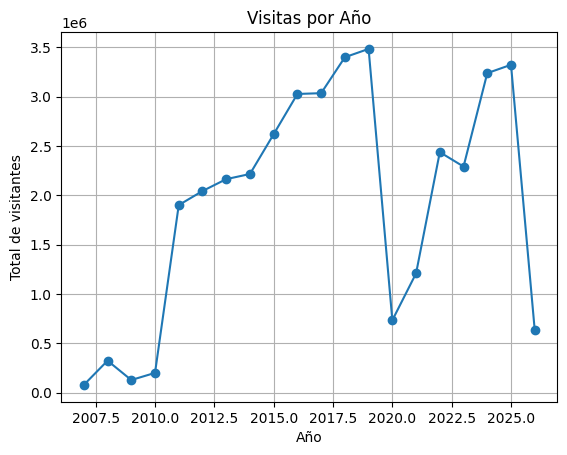

In [7]:
# 6. ANÁLISIS 1: VISITAS POR AÑO
#OJO AQUI EL AÑO DEBE TENER VALORES ENTEROS.
visitas_anio = df.groupby('ANIO')['TOTAL'].sum()

plt.figure()
visitas_anio.plot(marker='o')
plt.title("Visitas por Año")
plt.xlabel("Año")
plt.ylabel("Total de visitantes")
plt.grid()
plt.show()

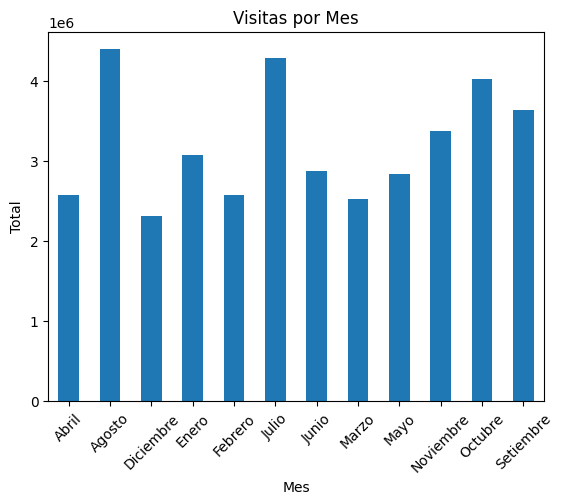

In [8]:
# 7. ANÁLISIS 2: VISITAS POR MES
visitas_mes = df.groupby('NOM_MES')['TOTAL'].sum()

plt.figure()
visitas_mes.plot(kind='bar')
plt.title("Visitas por Mes")
plt.xlabel("Mes")
plt.ylabel("Total")
plt.xticks(rotation=45)
plt.show()

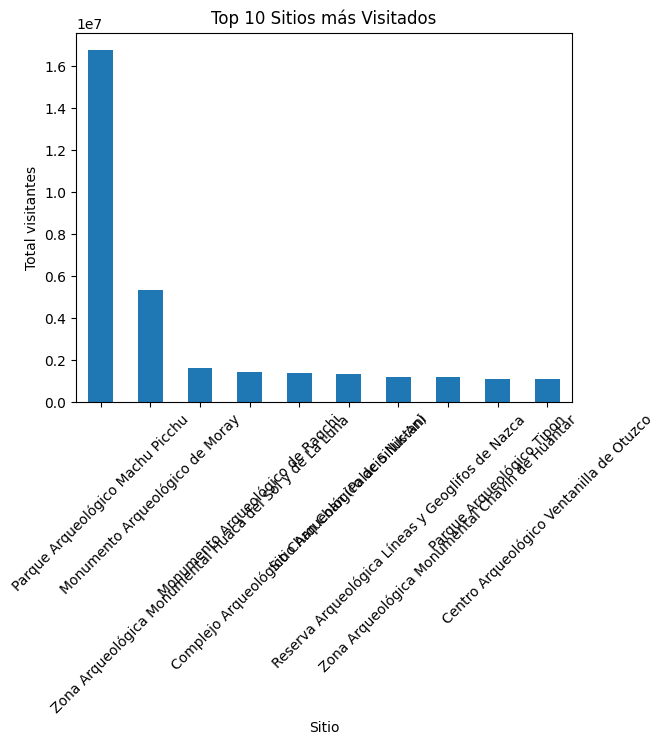

In [9]:
# 8. ANÁLISIS 3: TOP 10 SITIOS
top_sitios = df.groupby('NOM_MUSEO')['TOTAL'].sum().sort_values(ascending=False).head(10)

plt.figure()
top_sitios.plot(kind='bar')
plt.title("Top 10 Sitios más Visitados")
plt.xlabel("Sitio")
plt.ylabel("Total visitantes")
plt.xticks(rotation=45)
plt.show()

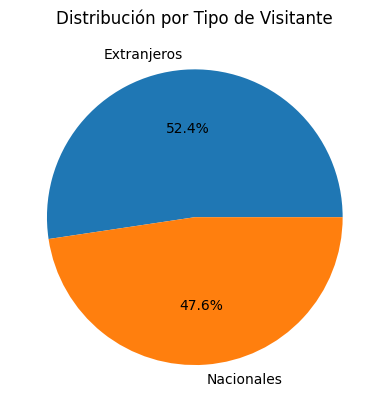

In [10]:
# 9. ANÁLISIS 4: TIPO DE VISITANTE
tipo = df.groupby('NOM_TIPO')['TOTAL'].sum()

plt.figure()
tipo.plot(kind='pie', autopct='%1.1f%%')
plt.title("Distribución por Tipo de Visitante")
plt.ylabel("")
plt.show()
